In [69]:
import pandas as pd
import numpy as np
import seaborn as sea
import matplotlib.pyplot as plt

In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
dataset = pd.read_csv("/content/drive/MyDrive/AI_ML_Foundation/datasets/Copy of world_population_data.csv")

In [72]:
dataset.head(10)

,rank,cca3,country,continent,2023 population,2022 population,2020 population,2015 population,2010 population,2000 population,1990 population,1980 population,1970 population,area (km²),density (km²),growth rate,world percentage
0,1,IND,India,Asia,1428627663,1417173173,1396387127,1322866505,1240613620,1059633675,870452165,696828385,557501301,3287590.0,481,0.81%,17.85%
1,2,CHN,China,Asia,1425671352,1425887337,1424929781,1393715448,1348191368,1264099069,1153704252,982372466,822534450,9706961.0,151,-0.02%,17.81%
2,3,USA,United States,North America,339996563,338289857,335942003,324607776,311182845,282398554,248083732,223140018,200328340,9372610.0,37,0.50%,4.25%
3,4,IDN,Indonesia,Asia,277534122,275501339,271857970,259091970,244016173,214072421,182159874,148177096,115228394,1904569.0,148,0.74%,3.47%
4,5,PAK,Pakistan,Asia,240485658,235824862,227196741,210969298,194454498,154369924,115414069,80624057,59290872,881912.0,312,1.98%,3.00%
5,6,NGA,Nigeria,Africa,223804632,218541212,208327405,183995785,160952853,122851984,95214257,72951439,55569264,923768.0,246,2.41%,2.80%
6,7,BRA,Brazil,South America,216422446,215313498,213196304,205188205,196353492,175873720,150706446,122288383,96369875,8515767.0,26,0.52%,2.70%
7,8,BGD,Bangladesh,Asia,172954319,171186372,167420951,157830000,148391139,129193327,107147651,83929765,67541860,147570.0,1329,1.03%,2.16%
8,9,RUS,Russia,Europe,144444359,144713314,145617329,144668389,143242599,146844839,148005704,138257420,130093010,17098242.0,9,-0.19%,1.80%
9,10,MEX,Mexico,North America,128455567,127504125,125998302,120149897,112532401,97873442,81720428,67705186,50289306,1964375.0,66,0.75%,1.60%


In [73]:
dataset.columns

Index(['rank', 'cca3', 'country', 'continent', '2023 population',
       '2022 population', '2020 population', '2015 population',
       '2010 population', '2000 population', '1990 population',
       '1980 population', '1970 population', 'area (km²)', 'density (km²)',
       'growth rate', 'world percentage'],
      dtype='object')

In [74]:
# Feature Engineering.
# Population change features

# 23 - 22, 22-20, 2020-15, 2015-10, 2010-2000, 2000-1990, 1990-1980, 1980-1970,

In [75]:
pop_dataset = dataset.copy()

In [76]:
pop_dataset['23-22 Population Change'] = pop_dataset['2023 population'] - pop_dataset['2022 population']

pop_dataset['22-20 Population Change'] = pop_dataset['2022 population'] - pop_dataset['2020 population']

pop_dataset['20-15 Population Change'] = pop_dataset['2020 population'] - pop_dataset['2015 population']

pop_dataset['15-10 Population Change'] = pop_dataset['2015 population'] - pop_dataset['2010 population']

pop_dataset['10-00 Population Change'] = pop_dataset['2010 population'] - pop_dataset['2000 population']

pop_dataset['00-90 Population Change'] = pop_dataset['2000 population'] - pop_dataset['1990 population']

pop_dataset['90-80 Population Change'] = pop_dataset['1990 population'] - pop_dataset['1980 population']

pop_dataset['80-70 Population Change'] = pop_dataset['1980 population'] - pop_dataset['1970 population']

In [77]:
pop_dataset.head(10)

,rank,cca3,country,continent,2023 population,2022 population,2020 population,2015 population,2010 population,2000 population,...,growth rate,world percentage,23-22 Population Change,22-20 Population Change,20-15 Population Change,15-10 Population Change,10-00 Population Change,00-90 Population Change,90-80 Population Change,80-70 Population Change
0,1,IND,India,Asia,1428627663,1417173173,1396387127,1322866505,1240613620,1059633675,...,0.81%,17.85%,11454490,20786046,73520622,82252885,180979945,189181510,173623780,139327084
1,2,CHN,China,Asia,1425671352,1425887337,1424929781,1393715448,1348191368,1264099069,...,-0.02%,17.81%,-215985,957556,31214333,45524080,84092299,110394817,171331786,159838016
2,3,USA,United States,North America,339996563,338289857,335942003,324607776,311182845,282398554,...,0.50%,4.25%,1706706,2347854,11334227,13424931,28784291,34314822,24943714,22811678
3,4,IDN,Indonesia,Asia,277534122,275501339,271857970,259091970,244016173,214072421,...,0.74%,3.47%,2032783,3643369,12766000,15075797,29943752,31912547,33982778,32948702
4,5,PAK,Pakistan,Asia,240485658,235824862,227196741,210969298,194454498,154369924,...,1.98%,3.00%,4660796,8628121,16227443,16514800,40084574,38955855,34790012,21333185
5,6,NGA,Nigeria,Africa,223804632,218541212,208327405,183995785,160952853,122851984,...,2.41%,2.80%,5263420,10213807,24331620,23042932,38100869,27637727,22262818,17382175
6,7,BRA,Brazil,South America,216422446,215313498,213196304,205188205,196353492,175873720,...,0.52%,2.70%,1108948,2117194,8008099,8834713,20479772,25167274,28418063,25918508
7,8,BGD,Bangladesh,Asia,172954319,171186372,167420951,157830000,148391139,129193327,...,1.03%,2.16%,1767947,3765421,9590951,9438861,19197812,22045676,23217886,16387905
8,9,RUS,Russia,Europe,144444359,144713314,145617329,144668389,143242599,146844839,...,-0.19%,1.80%,-268955,-904015,948940,1425790,-3602240,-1160865,9748284,8164410
9,10,MEX,Mexico,North America,128455567,127504125,125998302,120149897,112532401,97873442,...,0.75%,1.60%,951442,1505823,5848405,7617496,14658959,16153014,14015242,17415880


In [78]:
top_increases = pop_dataset.sort_values(by='23-22 Population Change', ascending=False).head(10)

top_decreases = pop_dataset.sort_values(by= '23-22 Population Change', ascending=True).head(10)


print("Top 10 Population Increased: ")
display(top_increases)
print("Top 10 Population Decreased: ")
display(top_decreases)
# Histplot

Top 10 Population Increased: 


,rank,cca3,country,continent,2023 population,2022 population,2020 population,2015 population,2010 population,2000 population,...,growth rate,world percentage,23-22 Population Change,22-20 Population Change,20-15 Population Change,15-10 Population Change,10-00 Population Change,00-90 Population Change,90-80 Population Change,80-70 Population Change
0,1,IND,India,Asia,1428627663,1417173173,1396387127,1322866505,1240613620,1059633675,...,0.81%,17.85%,11454490,20786046,73520622,82252885,180979945,189181510,173623780,139327084
5,6,NGA,Nigeria,Africa,223804632,218541212,208327405,183995785,160952853,122851984,...,2.41%,2.80%,5263420,10213807,24331620,23042932,38100869,27637727,22262818,17382175
4,5,PAK,Pakistan,Asia,240485658,235824862,227196741,210969298,194454498,154369924,...,1.98%,3.00%,4660796,8628121,16227443,16514800,40084574,38955855,34790012,21333185
14,15,COD,DR Congo,Africa,102262808,99010212,92853164,78656904,66391257,48616317,...,3.29%,1.28%,3252596,6157048,14196260,12265647,17774940,12628776,9278855,6556953
10,11,ETH,Ethiopia,Africa,126527060,123379924,117190911,102471895,89237791,67031867,...,2.55%,1.58%,3147136,6189013,14719016,13234104,22205924,19153794,12932604,6637223
3,4,IDN,Indonesia,Asia,277534122,275501339,271857970,259091970,244016173,214072421,...,0.74%,3.47%,2032783,3643369,12766000,15075797,29943752,31912547,33982778,32948702
21,22,TZA,Tanzania,Africa,67438106,65497748,61704518,52542823,45110527,34463704,...,2.96%,0.84%,1940358,3793230,9161695,7432296,10646823,8257692,6908353,5679467
12,13,PHL,Philippines,Asia,117337368,115559009,112190977,103031365,94636700,77958223,...,1.54%,1.47%,1778359,3368032,9159612,8394665,16678477,16399325,13139352,10983960
7,8,BGD,Bangladesh,Asia,172954319,171186372,167420951,157830000,148391139,129193327,...,1.03%,2.16%,1767947,3765421,9590951,9438861,19197812,22045676,23217886,16387905
13,14,EGY,Egypt,Africa,112716598,110990103,107465134,97723799,87252413,71371371,...,1.56%,1.41%,1726495,3524969,9741335,10471386,15881042,14156741,13466074,8966570


Top 10 Population Decreased: 


,rank,cca3,country,continent,2023 population,2022 population,2020 population,2015 population,2010 population,2000 population,...,growth rate,world percentage,23-22 Population Change,22-20 Population Change,20-15 Population Change,15-10 Population Change,10-00 Population Change,00-90 Population Change,90-80 Population Change,80-70 Population Change
40,41,UKR,Ukraine,Europe,36744634,39701739,43909666,44982564,45683020,48879755,...,-7.45%,0.46%,-2957105,-4207927,-1072898,-700456,-3196735,-2710062,1615897,2694834
11,12,JPN,Japan,Asia,123294513,123951692,125244761,127250933,128105431,126803861,...,-0.53%,1.54%,-657179,-1293069,-2006172,-854498,1301570,3117540,6062125,12207357
8,9,RUS,Russia,Europe,144444359,144713314,145617329,144668389,143242599,146844839,...,-0.19%,1.80%,-268955,-904015,948940,1425790,-3602240,-1160865,9748284,8164410
1,2,CHN,China,Asia,1425671352,1425887337,1424929781,1393715448,1348191368,1264099069,...,-0.02%,17.81%,-215985,957556,31214333,45524080,84092299,110394817,171331786,159838016
24,25,ITA,Italy,Europe,58870762,59037474,59500579,60232906,59822450,56966397,...,-0.28%,0.74%,-166712,-463105,-732327,410456,2856053,209836,427079,3005446
121,122,LBN,Lebanon,Asia,5353930,5489739,5662923,6398940,4995800,4320642,...,-2.47%,0.07%,-135809,-173184,-736017,1403140,675158,726942,629998,581911
109,110,BGR,Bulgaria,Europe,6687717,6781953,6979175,7309253,7592273,8097691,...,-1.39%,0.08%,-94236,-197222,-330078,-283020,-505418,-670087,-212828,397656
18,19,DEU,Germany,Europe,83294633,83369843,83328988,82073226,81325090,81551677,...,-0.09%,1.04%,-75210,40855,1255762,748136,-226587,2181481,1583493,-507880
104,105,SRB,Serbia,Europe,7149077,7221365,7358005,7519496,7653748,7935022,...,-1.00%,0.09%,-72288,-136640,-161491,-134252,-281274,-52507,210519,583477
90,91,GRC,Greece,Europe,10341277,10384971,10512232,10806641,11033783,11038109,...,-0.42%,0.13%,-43694,-127261,-294409,-227142,-4326,735854,995107,762275


/tmp/ipykernel_1892/765920141.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_increases, x='country', y='23-22 Population Change', palette='viridis')


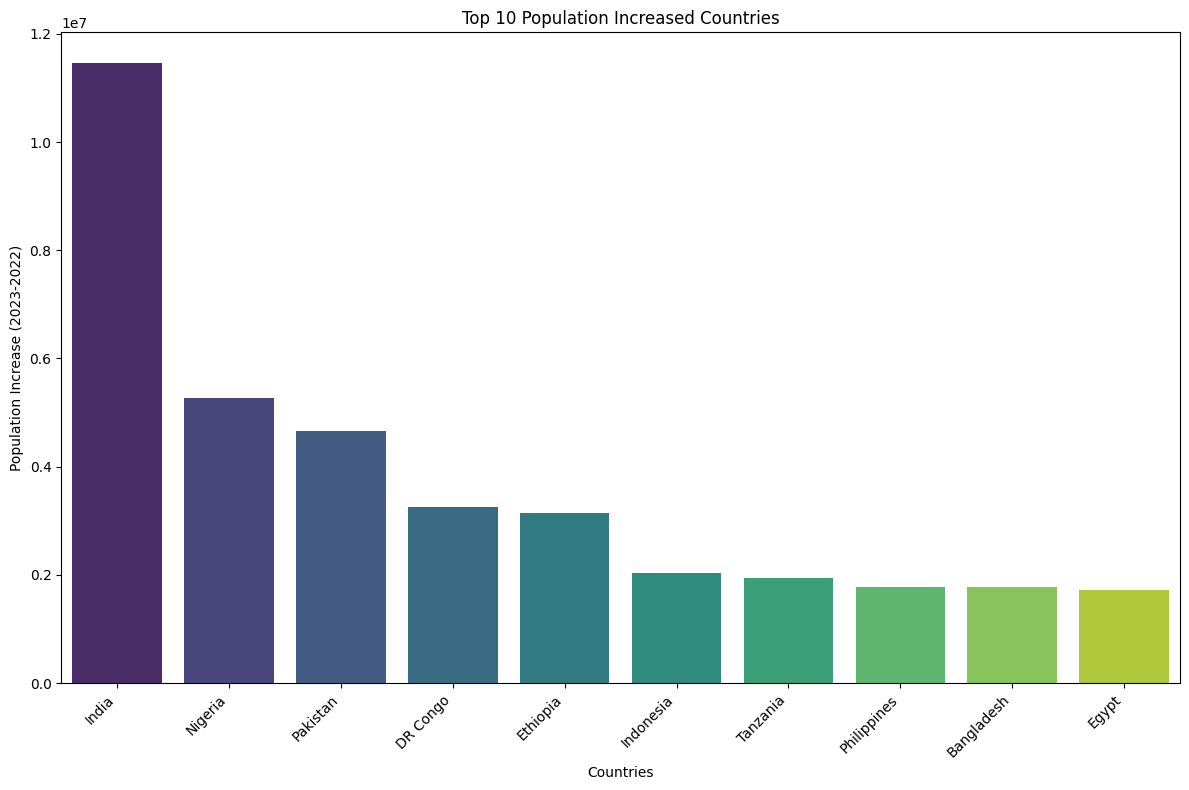

/tmp/ipykernel_1892/765920141.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_decreases, x='country', y='23-22 Population Change', palette='viridis')


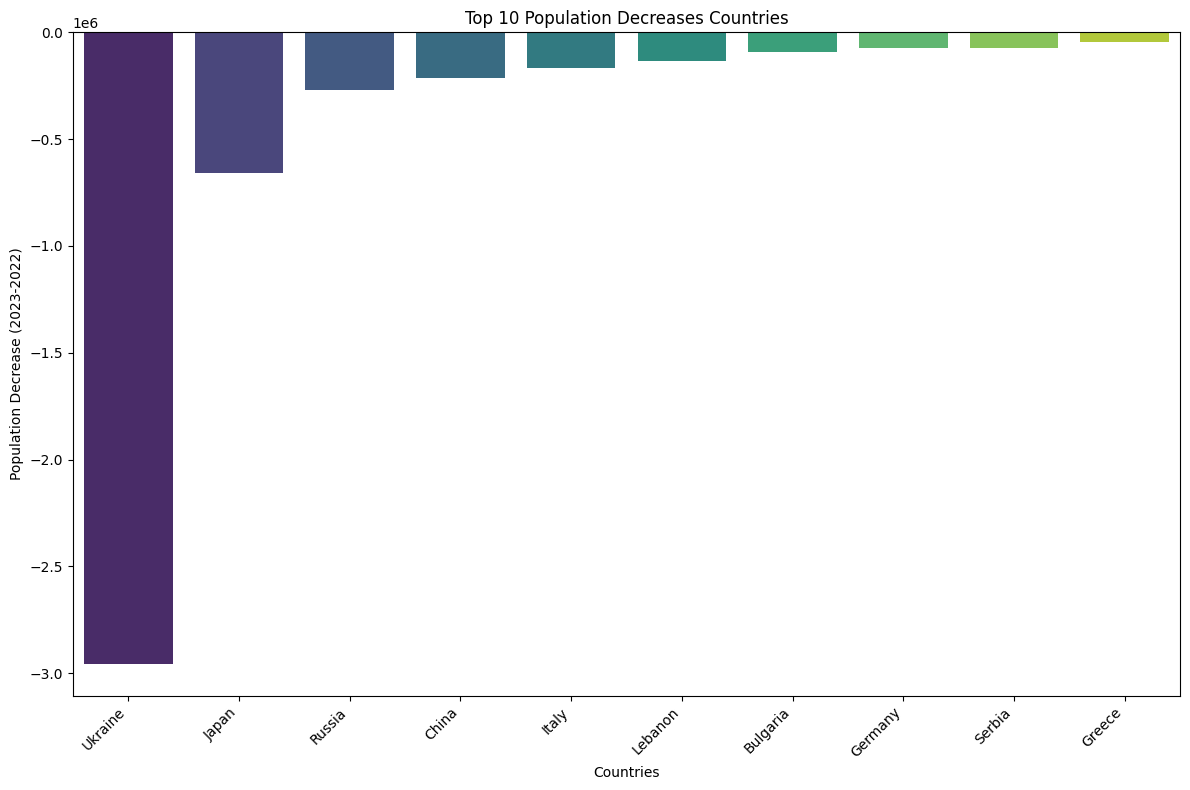

In [79]:
# 2023 - 22 Population changes
plt.figure(figsize=(12,8))
sea.barplot(data=top_increases, x='country', y='23-22 Population Change', palette='viridis')
plt.title("Top 10 Population Increased Countries")
plt.xlabel("Countries")
plt.ylabel('Population Increase (2023-2022)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
sea.barplot(data=top_decreases, x='country', y='23-22 Population Change', palette='viridis')
plt.title("Top 10 Population Decreases Countries")
plt.xlabel("Countries")
plt.ylabel('Population Decrease (2023-2022)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [80]:
top_increases = pop_dataset.sort_values(by='22-20 Population Change', ascending=False).head(10)

top_decreases = pop_dataset.sort_values(by= '22-20 Population Change', ascending=True).head(10)


print("Top 10 Population Increased: ")
# display(top_increases)
print("Top 10 Population Decreased: ")
# display(top_decreases)
# Histplot

Top 10 Population Increased: 
Top 10 Population Decreased: 


/tmp/ipykernel_1892/2935572568.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_increases, x='country', y='22-20 Population Change', palette='viridis')


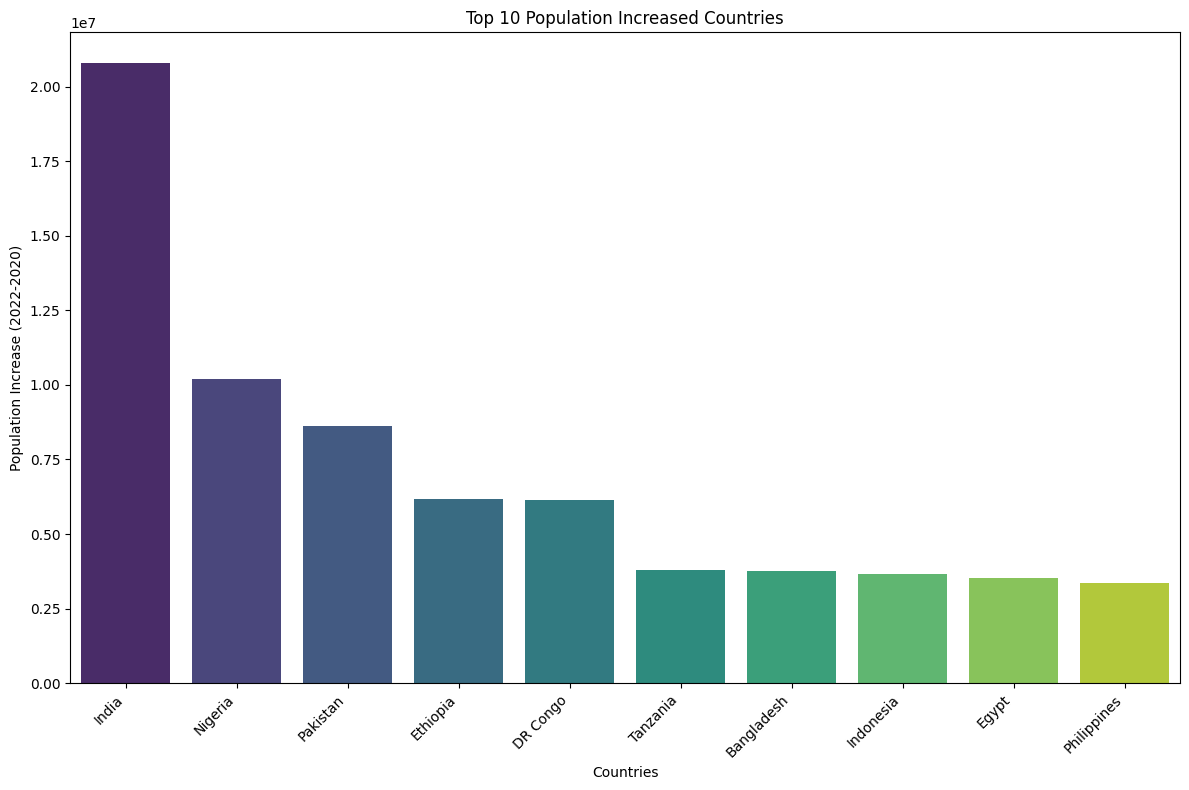

/tmp/ipykernel_1892/2935572568.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_decreases, x='country', y='22-20 Population Change', palette='viridis')


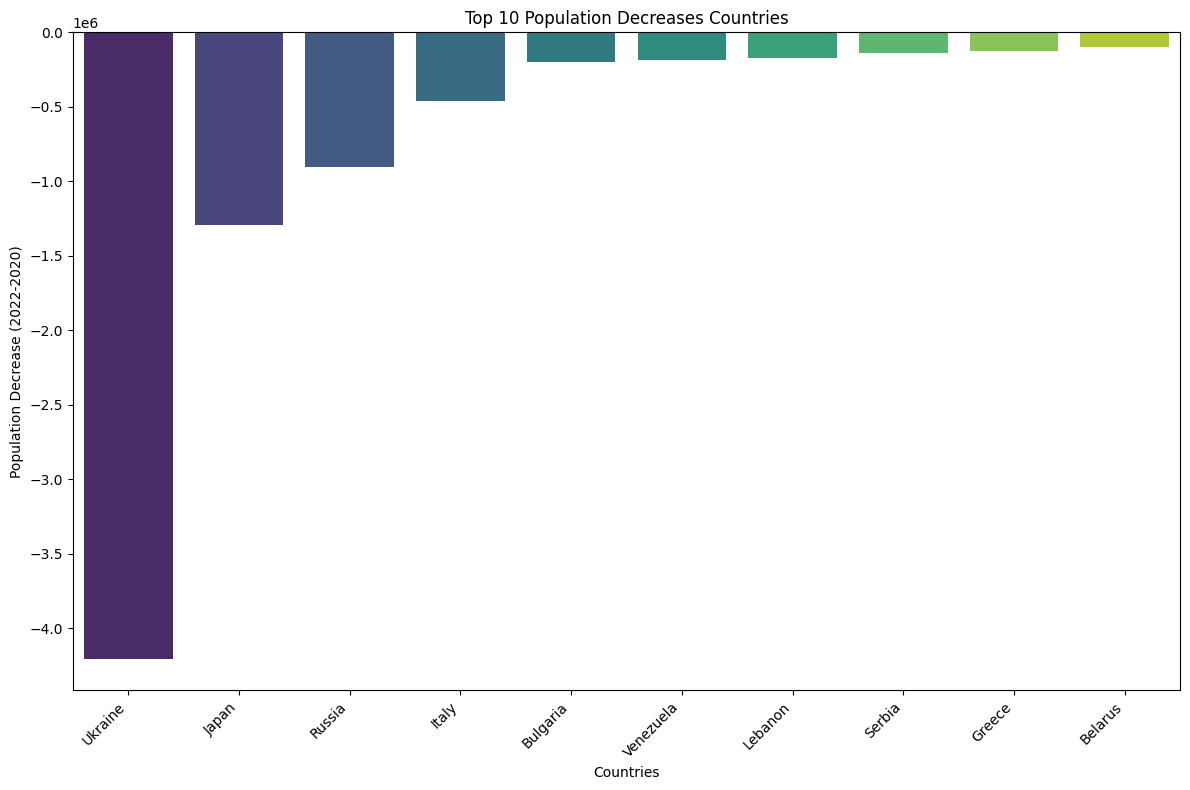

In [81]:
# 2022 - 2020 Population changes

plt.figure(figsize=(12,8))
sea.barplot(data=top_increases, x='country', y='22-20 Population Change', palette='viridis')
plt.title("Top 10 Population Increased Countries")
plt.xlabel("Countries")
plt.ylabel('Population Increase (2022-2020)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
sea.barplot(data=top_decreases, x='country', y='22-20 Population Change', palette='viridis')
plt.title("Top 10 Population Decreases Countries")
plt.xlabel("Countries")
plt.ylabel('Population Decrease (2022-2020)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top 10 Population Increased: 
Top 10 Population Decreased: 


/tmp/ipykernel_1892/60627894.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_increases, x='country', y='20-15 Population Change', palette='viridis')


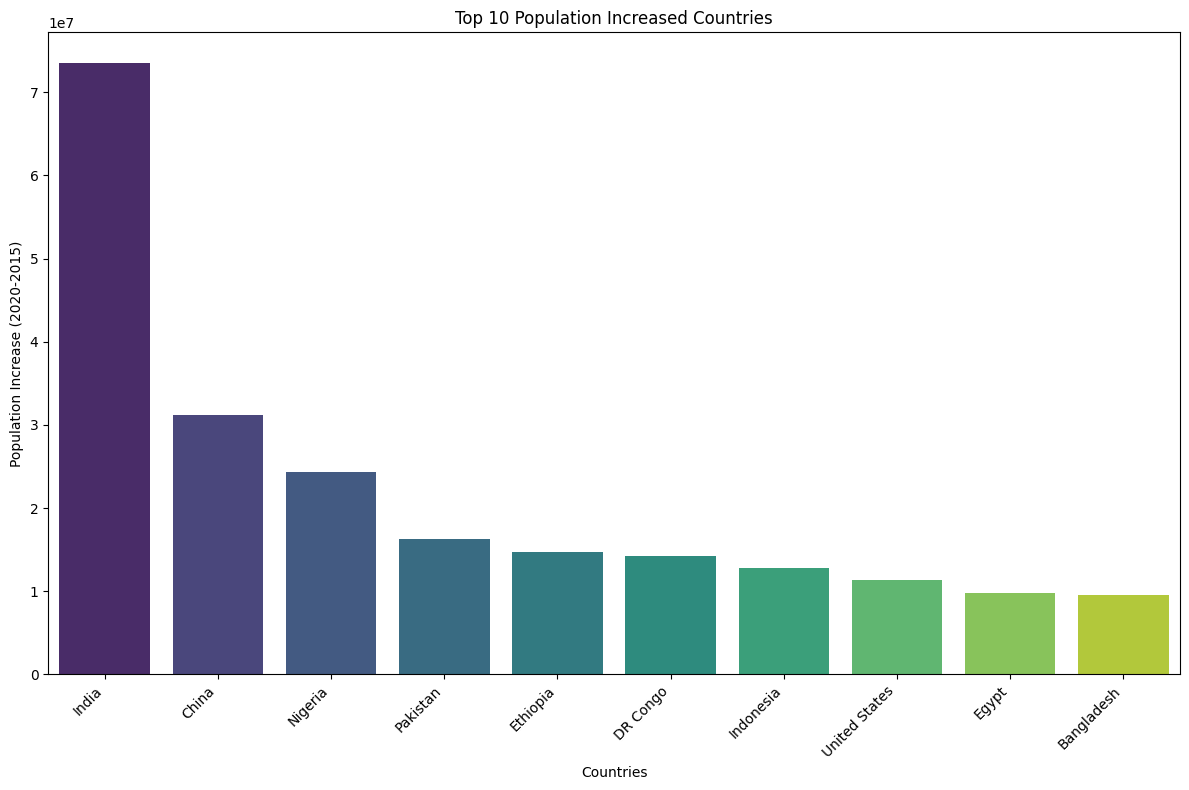

/tmp/ipykernel_1892/60627894.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_decreases, x='country', y='20-15 Population Change', palette='viridis')


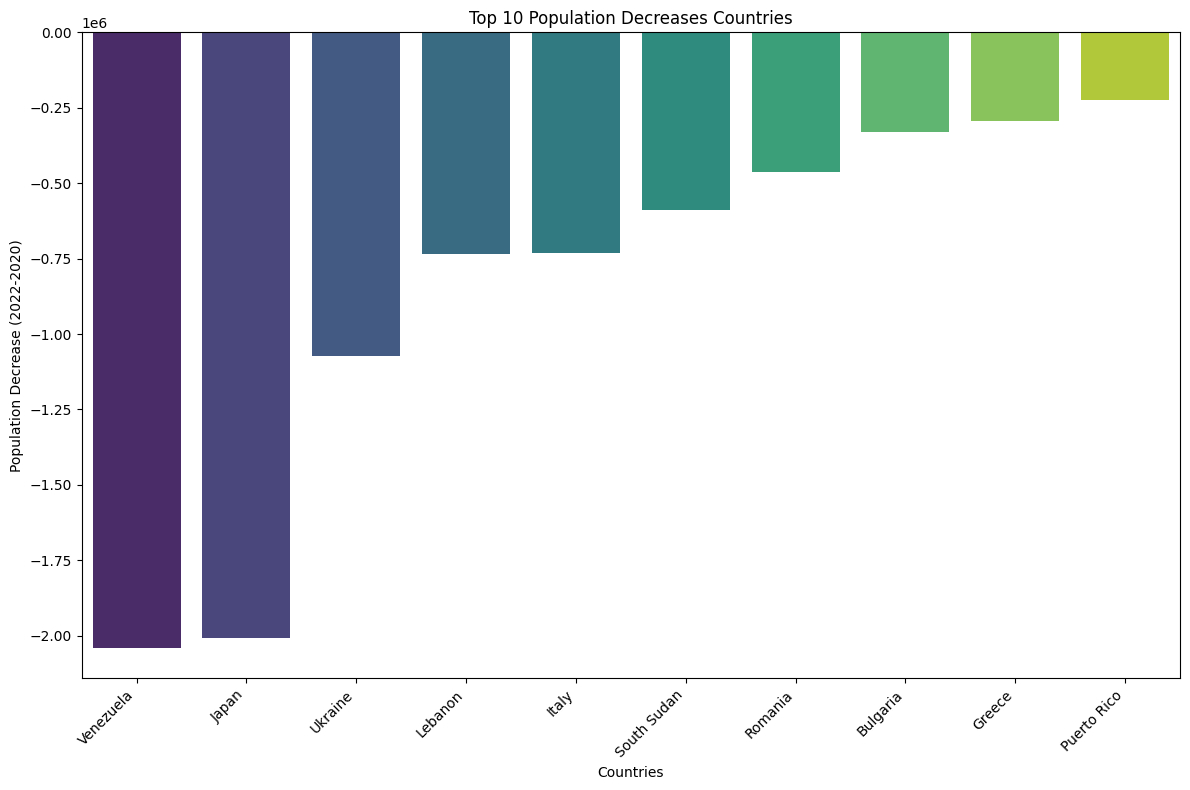

In [82]:
# For 2020 - 2015 Population Changes

top_increases = pop_dataset.sort_values(by='20-15 Population Change', ascending=False).head(10)

top_decreases = pop_dataset.sort_values(by='20-15 Population Change', ascending=True).head(10)


print("Top 10 Population Increased: ")
# display(top_increases)
print("Top 10 Population Decreased: ")
# display(top_decreases)

plt.figure(figsize=(12,8))
sea.barplot(data=top_increases, x='country', y='20-15 Population Change', palette='viridis')
plt.title("Top 10 Population Increased Countries")
plt.xlabel("Countries")
plt.ylabel('Population Increase (2020-2015)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
sea.barplot(data=top_decreases, x='country', y='20-15 Population Change', palette='viridis')
plt.title("Top 10 Population Decreases Countries")
plt.xlabel("Countries")
plt.ylabel('Population Decrease (2022-2020)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top 10 Population Increased: 
Top 10 Population Decreased: 


/tmp/ipykernel_1892/812164623.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_increases, x='country', y='15-10 Population Change', palette='viridis')


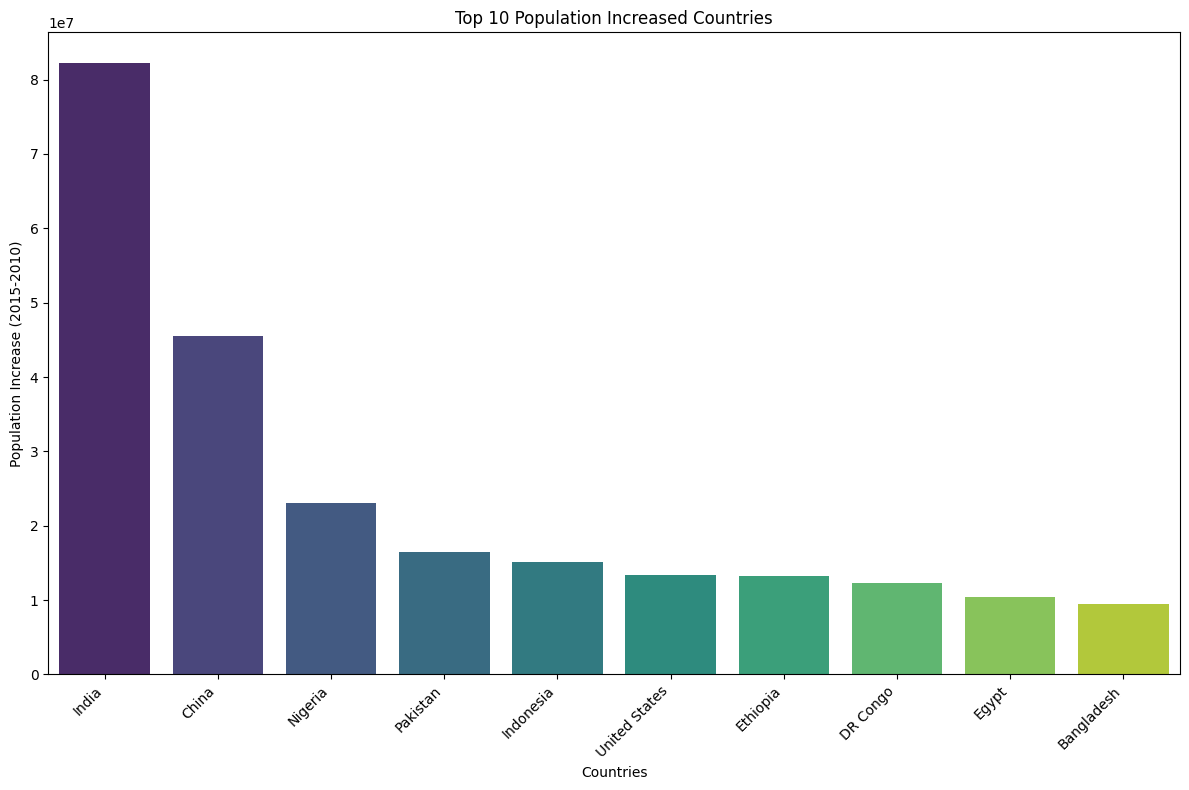

/tmp/ipykernel_1892/812164623.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_decreases, x='country', y='15-10 Population Change', palette='viridis')


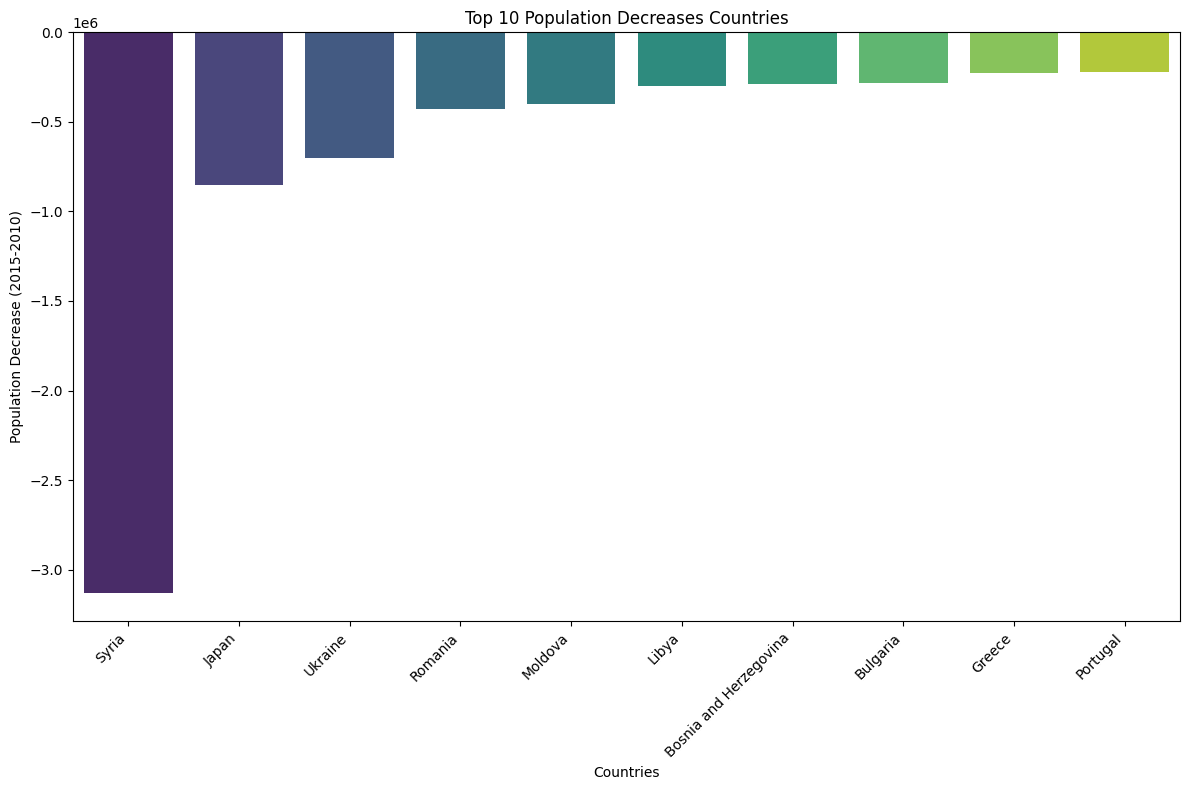

In [84]:

# For 2015 - 2010 Population Changes

top_increases = pop_dataset.sort_values(by='15-10 Population Change', ascending=False).head(10)

top_decreases = pop_dataset.sort_values(by='15-10 Population Change', ascending=True).head(10)


print("Top 10 Population Increased: ")
# display(top_increases)
print("Top 10 Population Decreased: ")
# display(top_decreases)

plt.figure(figsize=(12,8))
sea.barplot(data=top_increases, x='country', y='15-10 Population Change', palette='viridis')
plt.title("Top 10 Population Increased Countries")
plt.xlabel("Countries")
plt.ylabel('Population Increase (2015-2010)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
sea.barplot(data=top_decreases, x='country', y='15-10 Population Change', palette='viridis')
plt.title("Top 10 Population Decreases Countries")
plt.xlabel("Countries")
plt.ylabel('Population Decrease (2015-2010)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top 10 Population Increased: 
Top 10 Population Decreased: 


/tmp/ipykernel_1892/172977000.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_increases, x='country', y='10-00 Population Change', palette='viridis')


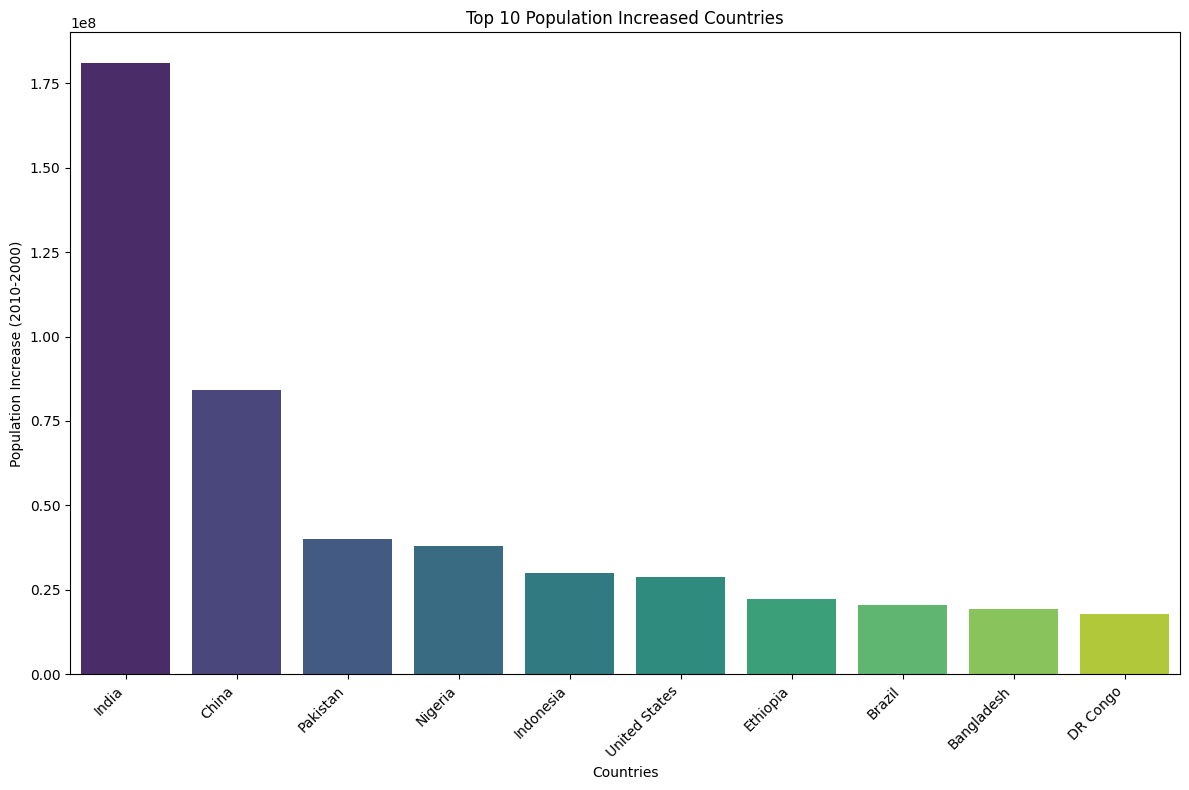

/tmp/ipykernel_1892/172977000.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_decreases, x='country', y='10-00 Population Change', palette='viridis')


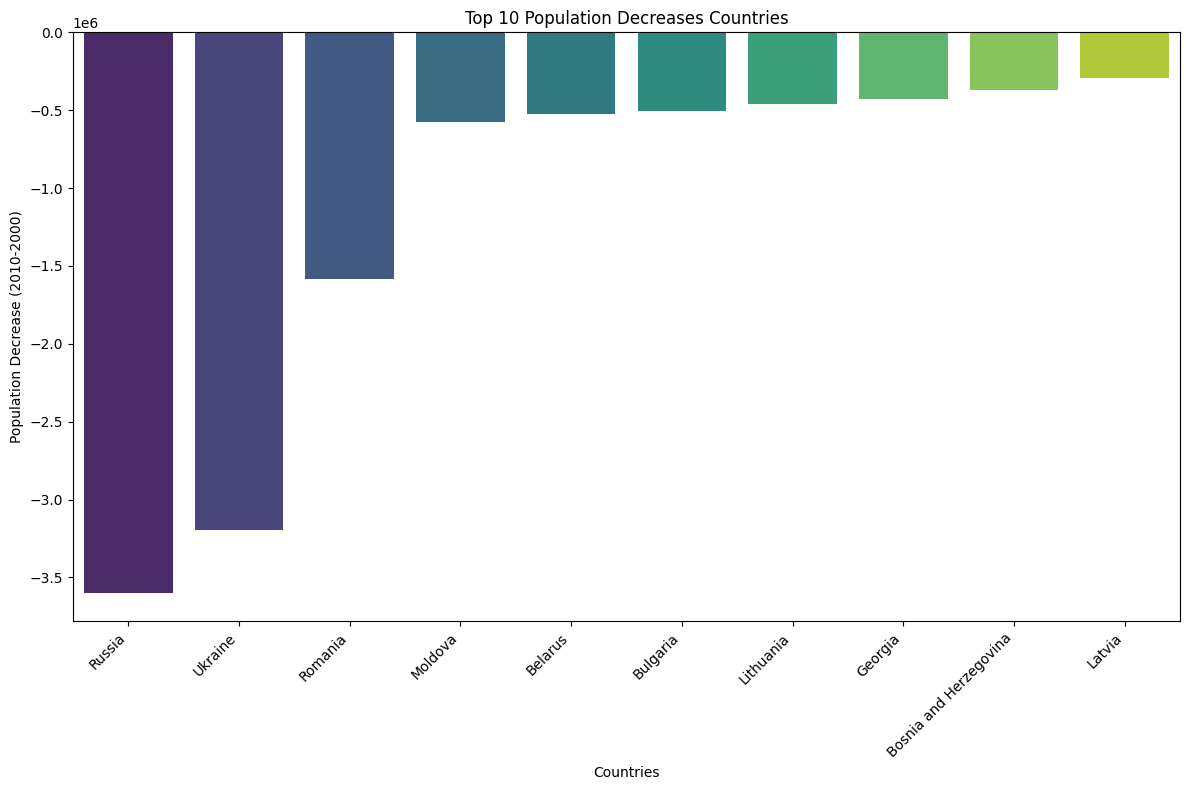

In [87]:
# 2010 - 2000 Population Changes

top_increases = pop_dataset.sort_values(by='10-00 Population Change', ascending=False).head(10)

top_decreases = pop_dataset.sort_values(by='10-00 Population Change', ascending=True).head(10)


print("Top 10 Population Increased: ")
# display(top_increases)
print("Top 10 Population Decreased: ")
# display(top_decreases)

plt.figure(figsize=(12,8))
sea.barplot(data=top_increases, x='country', y='10-00 Population Change', palette='viridis')
plt.title("Top 10 Population Increased Countries")
plt.xlabel("Countries")
plt.ylabel('Population Increase (2010-2000)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
sea.barplot(data=top_decreases, x='country', y='10-00 Population Change', palette='viridis')
plt.title("Top 10 Population Decreases Countries")
plt.xlabel("Countries")
plt.ylabel('Population Decrease (2010-2000)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top 10 Population Increased: 
Top 10 Population Decreased: 


/tmp/ipykernel_1892/2209892377.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_increases, x='country', y='00-90 Population Change', palette='viridis')


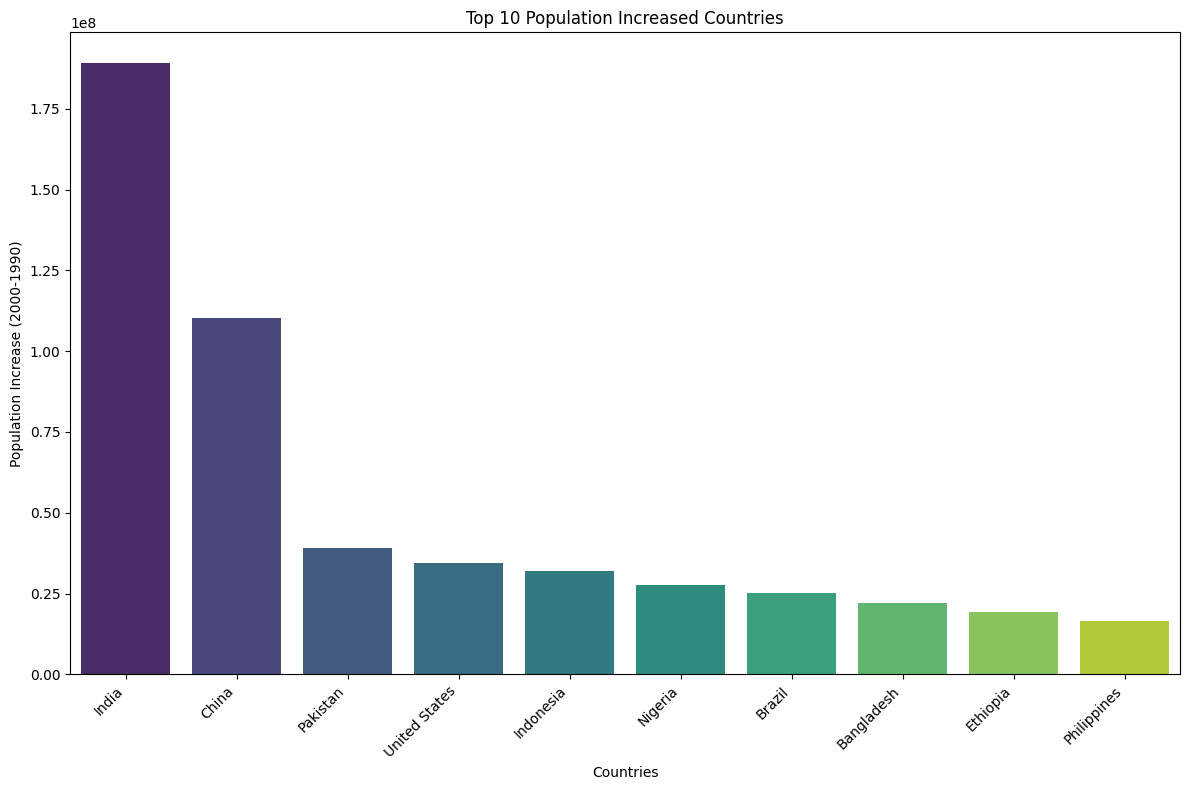

/tmp/ipykernel_1892/2209892377.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_decreases, x='country', y='00-90 Population Change', palette='viridis')


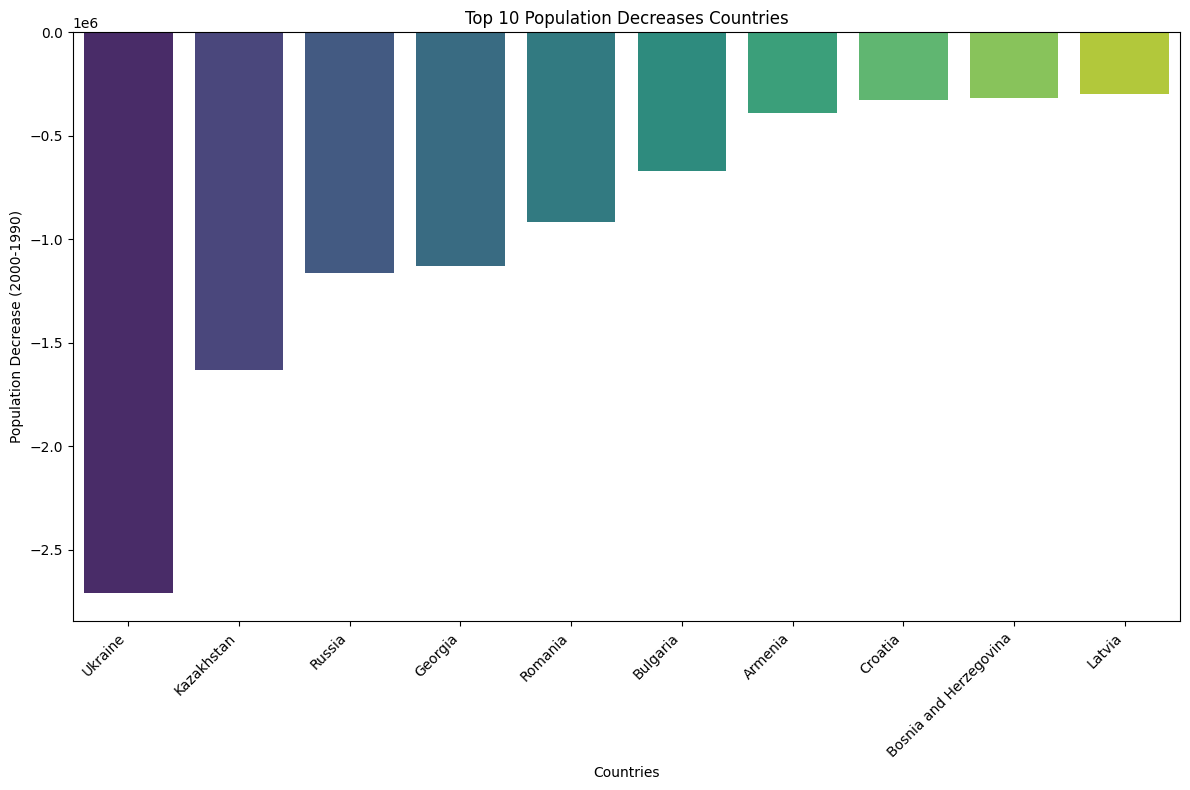

In [88]:
# 2000- 1990

top_increases = pop_dataset.sort_values(by='00-90 Population Change', ascending=False).head(10)

top_decreases = pop_dataset.sort_values(by='00-90 Population Change', ascending=True).head(10)


print("Top 10 Population Increased: ")
# display(top_increases)
print("Top 10 Population Decreased: ")
# display(top_decreases)

plt.figure(figsize=(12,8))
sea.barplot(data=top_increases, x='country', y='00-90 Population Change', palette='viridis')
plt.title("Top 10 Population Increased Countries")
plt.xlabel("Countries")
plt.ylabel('Population Increase (2000-1990)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
sea.barplot(data=top_decreases, x='country', y='00-90 Population Change', palette='viridis')
plt.title("Top 10 Population Decreases Countries")
plt.xlabel("Countries")
plt.ylabel('Population Decrease (2000-1990)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top 10 Population Increased: 
Top 10 Population Decreased: 


/tmp/ipykernel_1892/571472670.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_increases, x='country', y='90-80 Population Change', palette='viridis')


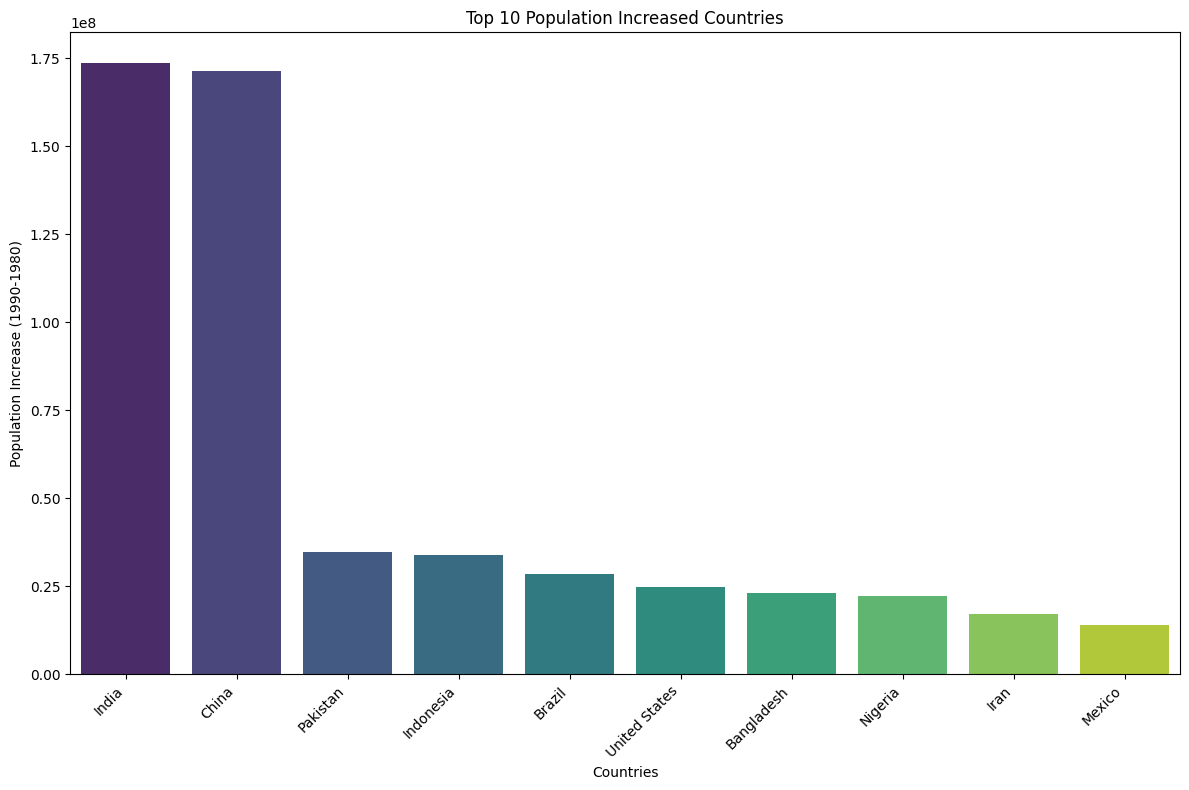

/tmp/ipykernel_1892/571472670.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_decreases, x='country', y='90-80 Population Change', palette='viridis')


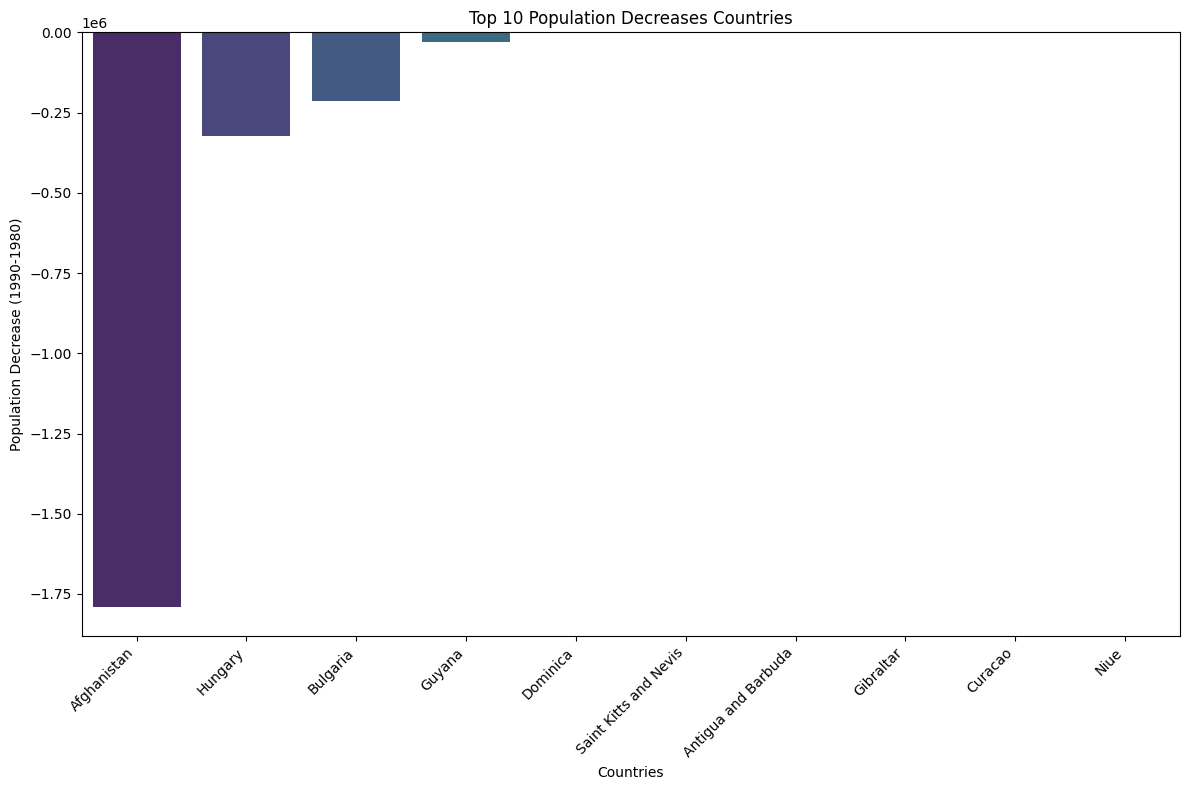

In [89]:
# 1990 - 1980 Population Changes

top_increases = pop_dataset.sort_values(by='90-80 Population Change', ascending=False).head(10)

top_decreases = pop_dataset.sort_values(by='90-80 Population Change', ascending=True).head(10)


print("Top 10 Population Increased: ")
# display(top_increases)
print("Top 10 Population Decreased: ")
# display(top_decreases)

plt.figure(figsize=(12,8))
sea.barplot(data=top_increases, x='country', y='90-80 Population Change', palette='viridis')
plt.title("Top 10 Population Increased Countries")
plt.xlabel("Countries")
plt.ylabel('Population Increase (1990-1980)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
sea.barplot(data=top_decreases, x='country', y='90-80 Population Change', palette='viridis')
plt.title("Top 10 Population Decreases Countries")
plt.xlabel("Countries")
plt.ylabel('Population Decrease (1990-1980)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top 10 Population Increased: 
Top 10 Population Decreased: 


/tmp/ipykernel_1892/3997970511.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_increases, x='country', y='80-70 Population Change', palette='viridis')


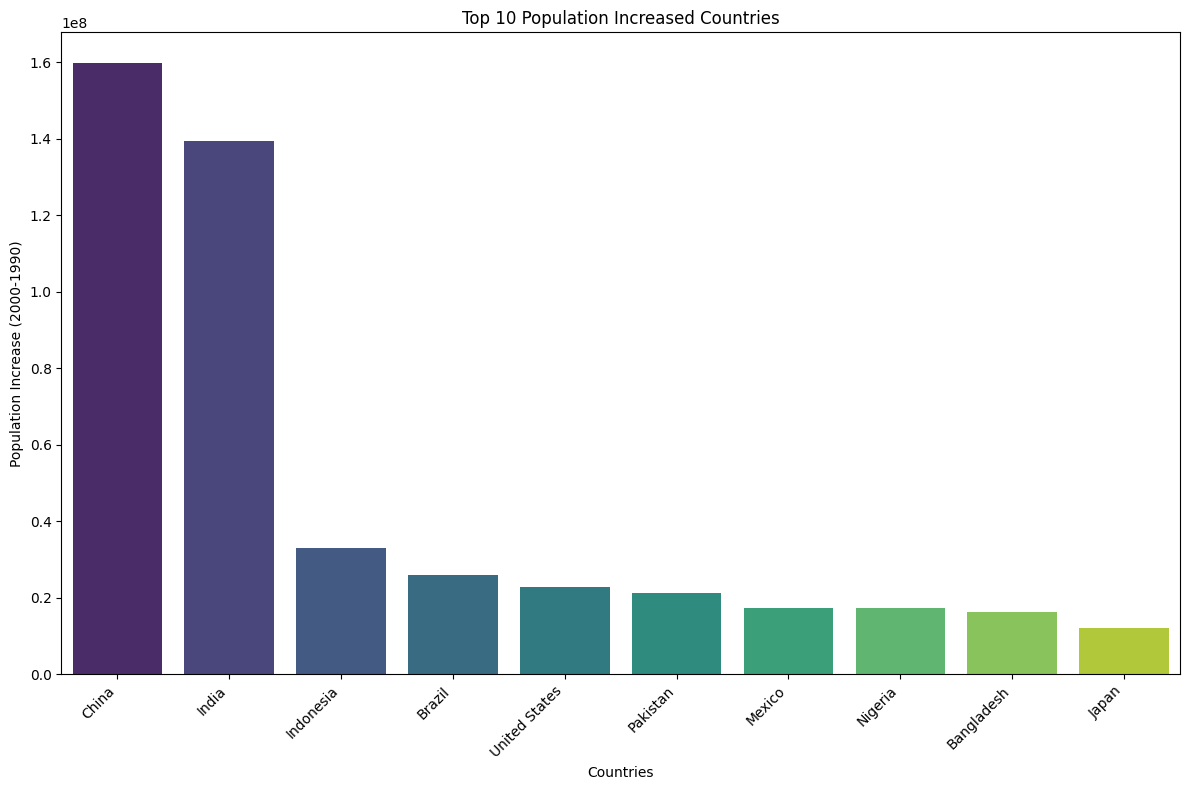

/tmp/ipykernel_1892/3997970511.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=top_decreases, x='country', y='80-70 Population Change', palette='viridis')


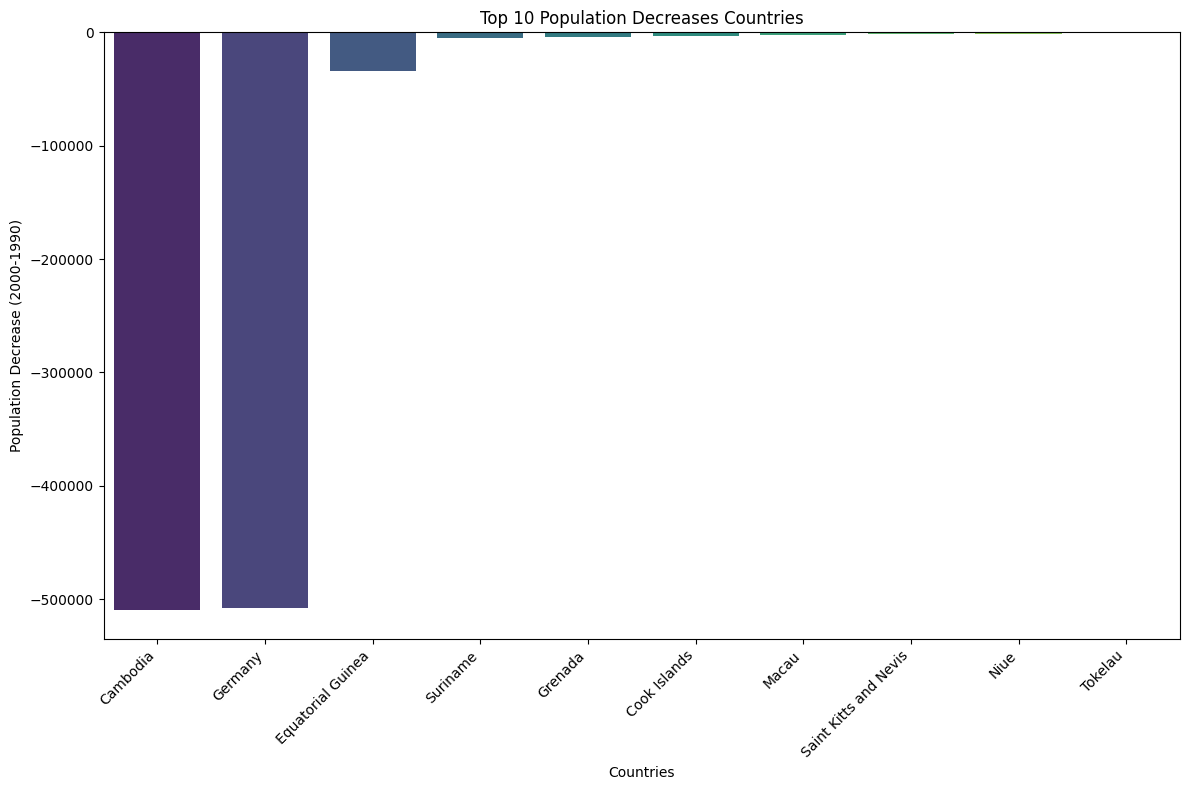

In [90]:
# 1980 - 1970 Population change

top_increases = pop_dataset.sort_values(by='80-70 Population Change', ascending=False).head(10)

top_decreases = pop_dataset.sort_values(by='80-70 Population Change', ascending=True).head(10)


print("Top 10 Population Increased: ")
# display(top_increases)
print("Top 10 Population Decreased: ")
# display(top_decreases)

plt.figure(figsize=(12,8))
sea.barplot(data=top_increases, x='country', y='80-70 Population Change', palette='viridis')
plt.title("Top 10 Population Increased Countries")
plt.xlabel("Countries")
plt.ylabel('Population Increase (2000-1990)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
sea.barplot(data=top_decreases, x='country', y='80-70 Population Change', palette='viridis')
plt.title("Top 10 Population Decreases Countries")
plt.xlabel("Countries")
plt.ylabel('Population Decrease (2000-1990)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [85]:
pop_dataset.columns

Index(['rank', 'cca3', 'country', 'continent', '2023 population',
       '2022 population', '2020 population', '2015 population',
       '2010 population', '2000 population', '1990 population',
       '1980 population', '1970 population', 'area (km²)', 'density (km²)',
       'growth rate', 'world percentage', '23-22 Population Change',
       '22-20 Population Change', '20-15 Population Change',
       '15-10 Population Change', '10-00 Population Change',
       '00-90 Population Change', '90-80 Population Change',
       '80-70 Population Change'],
      dtype='object')

In [94]:
if pd.api.types.is_string_dtype(pop_dataset['growth rate']):
    pop_dataset['growth rate'] = pop_dataset['growth rate'].str.replace("%", "").astype(float) / 100

display(pop_dataset[['country', 'growth rate']].head())

,country,growth rate
0,India,0.0081
1,China,-0.0002
2,United States,0.0050
3,Indonesia,0.0074
4,Pakistan,0.0198


In [95]:
pop_dataset.head()

,rank,cca3,country,continent,2023 population,2022 population,2020 population,2015 population,2010 population,2000 population,...,growth rate,world percentage,23-22 Population Change,22-20 Population Change,20-15 Population Change,15-10 Population Change,10-00 Population Change,00-90 Population Change,90-80 Population Change,80-70 Population Change
0,1,IND,India,Asia,1428627663,1417173173,1396387127,1322866505,1240613620,1059633675,...,0.0081,17.85%,11454490,20786046,73520622,82252885,180979945,189181510,173623780,139327084
1,2,CHN,China,Asia,1425671352,1425887337,1424929781,1393715448,1348191368,1264099069,...,-0.0002,17.81%,-215985,957556,31214333,45524080,84092299,110394817,171331786,159838016
2,3,USA,United States,North America,339996563,338289857,335942003,324607776,311182845,282398554,...,0.0050,4.25%,1706706,2347854,11334227,13424931,28784291,34314822,24943714,22811678
3,4,IDN,Indonesia,Asia,277534122,275501339,271857970,259091970,244016173,214072421,...,0.0074,3.47%,2032783,3643369,12766000,15075797,29943752,31912547,33982778,32948702
4,5,PAK,Pakistan,Asia,240485658,235824862,227196741,210969298,194454498,154369924,...,0.0198,3.00%,4660796,8628121,16227443,16514800,40084574,38955855,34790012,21333185


In [99]:
import plotly.express as px

# Create a choropleth map for '23-22 Population Change'
fig = px.choropleth(
    pop_dataset,
    locations="cca3",
    color="10-00 Population Change",
    hover_name="country",
    color_continuous_scale=px.colors.sequential.Plasma,
    title='World Population Change (2010-2000)'
)

fig.show()

In [101]:
import plotly.express as px

fig = px.scatter(
    pop_dataset,
    x='area (km²)',
    y='2023 population',
    color='continent',
    hover_name='country',
    log_x=True, # Log scale for area due to large range
    log_y=True, # Log scale for population due to large range
    size='2023 population', # Size markers by population
    title='Area vs. 2023 Population by Continent'
)

fig.show()

This scatter plot is interactive! You can:

*   **Hover** over points to see country details.
*   **Zoom** in and out using your mouse wheel or the controls on the plot.
*   **Pan** by clicking and dragging.
*   **Toggle continents** on/off by clicking on their names in the legend.

I've used logarithmic scales for both axes and sized the markers by population to better handle the wide range of values and highlight differences. This should give you some interesting insights into population distribution relative to land area across continents.

This interactive map visualizes the population change between 2023 and 2022. You can hover over countries to see their specific population change and use the controls to zoom and pan.

In [86]:
dataset.isnull().sum()

,0
rank,0
cca3,0
country,0
continent,0
2023 population,0
2022 population,0
2020 population,0
2015 population,0
2010 population,0
2000 population,0
